<a href="https://colab.research.google.com/github/prestonmorg/Covid-STAAR/blob/main/notebooks/Covid_STAAR_Algebra_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# First we read in the data from the GitHub repo and create a dataframe.
data_url = "https://raw.githubusercontent.com/prestonmorg/Covid-STAAR/refs/heads/main/data/Cleaned_STAAR_Cumulative_Scores_2026.csv"
df = pd.read_csv(data_url)
df = df[df['subject'] == 'Algebra_I']

# We can then create 2 seperate, filtered dataframes. One that counts the sums
# of the appropriate counts for the Pre-COVID era (i.e. before 2020), and one
# that counts the sums of the appropriate counts for the Post-COVID era (i.e.
# after 2020). This helps set up the appropriate contingency table necessary
# for the Chi-Squared and Cramer's V analysis and values.
pre_sums = df.loc[df['year'] < 2020, df.columns.str.endswith('count')].sum()
post_sums = df.loc[df['year'] > 2020, df.columns.str.endswith('count')].sum()
con_table = pd.DataFrame([pre_sums, post_sums], index = ['Pre-COVID', 'Post-COVID'])

print(con_table)

            unsatisfactory_count  approaches_to_meets_count  advanced_count
Pre-COVID                 577042                    1774874          789095
Post-COVID                629199                    1356273          732263


Printing our contingency table here is just a sanity check for one of the important assumptions for running the Chi-Squared test. It is clear to see that all of our counts are much larger than the minimum amount ($5$).

In [2]:
# Here we run the 'chi2_contingency' function from the 'scipy.stats' library.
# We can then use the chi-squared value alongside 'n' (the number of tests) and
# 'min_dim' (which is essentially the smaller value between the number of rows
# and the number of columns for our contingency table).
chi2, p, dof, expected = chi2_contingency(con_table)
n = con_table.values.sum()
min_dim = min(con_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-Value: {p:.2f}")
print(f"Cramer's V: {cramers_v:.4f}")

Chi-Squared Statistic: 29916.54
P-Value: 0.00
Cramer's V: 0.0715


The code block above shows our initial reading of the dataset alongside our Chi-Squared and Cramér's V analysis. While a Chi-Squared independence analysis is usually enough, our extremely large $N$ (i.e. the number of test takers between the two eras) is going to cause extreme fluctuations in the difference between the associated numbers for each category for both eras. This will make our Chi-Squared test immediately claim a significant difference between the eras, and we can see that it causaed our $p$ value to be essentially non-existent.

This is why it's integral that we find the Cramér's V value. This value tells us how strong the relationship is. In our situation, our Cramér's V value is measuring how strong the impact of COVID was on the overall scoring distributions of the STAAR test. The formula for finding Cramér's V is as follows.
$$V=\sqrt{\frac{χ^2}{N*(k-1)}}$$
Where $χ^2$ is the Chi-Squared value obtained from our contingency table, $N$ is the number of tests in the dataset, and $k$ is the minimum dimension of our data (i.e. the number of rows or columns in our contingency table, whichever is smaller).

>Our code block above yields us a Chi-Squares value of $29916.54$ and a Cramér's V value of $0.0715$. This large Chi-Squared value follows the discussion above noting that the large number of samples will inflate the Chi-Squared value due to the inherit larger deviance of the distributions between eras. Our Cramér's V will will give us more information about how much COVID actually impacted the distribution of scores. Our value of $0.0715$ indicates that COVID-19 had neglible impact on the distribution of student scores across the $3$ scoring categories, since it was quite small (smaller than $0.10$).

In [3]:
# To start our logistic regression analysis, we first want to define what a
# 'passing' and 'failing' score would look like within our dataframe, and have
# an associated number of testers that fall within those categories.
#
# Creating a copy of our original dataframe lets us alter the data and its
# appearance without interfering with any future tests we might want to run.
df_model = df.copy().sort_values('year')
df_model['passed'] = df_model['advanced_count'] + df_model['approaches_to_meets_count']
df_model['failed'] = df_model['unsatisfactory_count']

# We can then create the necessary variables to help track our proportion of
# what we deemed to be a failing and a passing score between the two eras (i.e.
# pre COVID and post COVID). Making these binary values helps make our logistic
# regression process smoother.
df_model['post_covid'] = (df_model['year'] > 2020).astype(int)

# These next two created variables are for our ITS analysis we run in the next
# code block. The names pretty much explain what they are tracking. The first
# variable just tracks the time elapsed from 2012, which is the first year that
# we have data on the STAAR test. The second variable tracks the number of years
# elapsed since COVID happened, being put to 0 for all of the years prior to
# COVID occurring.
df_model['time_since_2012'] = df_model['year'] - 2012
df_model['time_since_COVID'] = np.where(df_model['year'] > 2020, df_model['year'] - 2020, 0)

# We can then use the 'statsmodels' built in general linear model to build our
# logistic regression.
log_reg_model = smf.glm(formula = "np.column_stack((passed, failed)) ~ post_covid",
                data = df_model,
                family = sm.families.Binomial()).fit()

# We can then pull the coefficient for our independent variable which describes
# the log-odds for the pre and post COVID performance. Since this number isn't
# as easy to interpret, we exponentiate it to have a better interpreation of the
# variable.
#
# The 'Odds Ratio' measures the increased/decreased odds a student has of passing
# between the two eras (i.e. pre-COVID and post-COVID).
post_COVID_coef_log = log_reg_model.params['post_covid']
log_odds_ratio = np.exp(post_COVID_coef_log)

# What we can do after extracting the odds ratio from our logistic regression
# is compute it ourselves straight from the data. We do this by first finding
# the pass rates for both pre-COVID and post-COVID, using those percentages to
# find the pass:fail ratio, and then using those ratios to find the post:pre
# pass ratio.
post_pass_rate = df_model[(df_model['post_covid'] == 1)]['passed'].sum() / (
    df_model[(df_model['post_covid'] == 1)]['passed'].sum() +
    df_model[(df_model['post_covid'] == 1)]['failed'].sum()
)
pre_pass_rate = df_model[(df_model['post_covid'] == 0)]['passed'].sum() / (
    df_model[(df_model['post_covid'] == 0)]['passed'].sum() +
    df_model[(df_model['post_covid'] == 0)]['failed'].sum()
)

print(f"Odds Ratio from Logistic Regression: {log_odds_ratio:.4f}")
print(f"Post-Covid Pass Rate: {post_pass_rate:.2f}%")
print(f"Pre-Covid Pass Rate: {pre_pass_rate:.2f}%")

Odds Ratio from Logistic Regression: 0.7470
Post-Covid Pass Rate: 0.77%
Pre-Covid Pass Rate: 0.82%


In order to analyze our dataset beyond the Cramér's V value obtained in the previous block, we can run a Logistic Regression and interpret the associated coefficients. Since Logistic Regression gives us coefficients as log-odds, we can exponentiate these values to interpret them as odds ratios. Depending on what the variable is specifically looking at, its associated odds ratio can tell us percent change either between COVID eras (i.e. pre-COVID and post-COVID) or throughout the years.

In our base Logistic Regression, we started out by assigning binary values to years that were either before COVID (given a value of $0$) or after COVID (given a value of $1$). Using that as our sole independent variable, we ran a Logistic Regression that would predict the log-odds of a student passing the Algebra I STAAR test given the binary value of the era that test was taken in. We then translated this to the odds-ratio described in the paragraph above.

>The odds-ratio value we obtained through the base Logistic Regression was $0.7470$. This means that when we only look at the pre and post COVID eras and ignore the time trends (which will be addressed in the following block), a student in the post-COVID era has a $25.30\%$ decrease in odds of passing the Algebra I STAAR test as opposed to a student in the pre-COVID era.

One important thing to note is that this decrease in odds does not translate to a direct percent increase in the number of students who passed pre-COVID versus post-COVID, and is also not a measure of how the passing percentage changed between the two eras. We can see that while our odds ratio explains a decreased of about $25\%$ for the odds of a student passing in the post-COVID era versus the pre-COVID era, our actual percentage rate for passing went from around $82\%$ pre-COVID to $77\%$ post-COVID.

In [4]:
# Using the 'statsmodel' package plus the other variables defined in the
# previous code block, we can create our ITS model and interpret its results.
its_model = smf.glm(formula = "np.column_stack((passed, failed)) ~ post_covid + time_since_2012 + time_since_COVID",
                    data = df_model,
                    family = sm.families.Binomial()).fit()

# We can once again pull the coefficients of our independent variables and
# transform the log-odds that we're given into an odds ratio that will help us
# more easily interpret what is happening with our data here.
post_COVID_coef_ITS = its_model.params['post_covid']
pre_COVID_trajectory = its_model.params['time_since_2012']
post_COVID_trajectory = its_model.params['time_since_COVID']

its_odds_ratio = np.exp(post_COVID_coef_ITS)
its_pre_trajectory_ratio = np.exp(pre_COVID_trajectory)
its_post_trajectory_ratio = np.exp(post_COVID_trajectory)

# The interpretation of each independent variable is as follows.
#
# The 'Odds Ratio' variable is the same as it was for the previous logistic
# regression. That is, by what percent do the odds of a student passing pre-COVID
# versus post-COVID increase or decrease by.
#
# The 'Pre Trajectory Ratio' measures the percent increase or decrease of the odds
# that a student has of passing in the years leading up to COVID.
#
# The 'Compounded Post Trajectory Ratio' measures the percent increase or
# decrease from the original pre-COVID odds ratio that a student has of passing
# in the years following COVID.
#
# The 'Overall Post-COVID Odds Ratio' is the final  percent inccrease or decrease
# in the odds a student has of passing the Algebra I STAAR year by year since COVID
# happened.
print(f"Odds Ratio: {its_odds_ratio:.4f}")
print(f"Pre Trajectory Ratio: {its_pre_trajectory_ratio:.4f}")
print(f"Compounded Post Trajectory Ratio: {its_post_trajectory_ratio:.4f}")
print(f"Overall Post-COVID Odds Ratio: {(its_pre_trajectory_ratio*its_post_trajectory_ratio):.4f}")
print(its_model.summary())

Odds Ratio: 0.4696
Pre Trajectory Ratio: 1.0307
Compounded Post Trajectory Ratio: 1.0676
Overall Post-COVID Odds Ratio: 1.1004
                                                Generalized Linear Model Regression Results                                                 
Dep. Variable:     ['np.column_stack((passed, failed))[0]', 'np.column_stack((passed, failed))[1]']   No. Observations:                   14
Model:                                                                                          GLM   Df Residuals:                       10
Model Family:                                                                              Binomial   Df Model:                            3
Link Function:                                                                                Logit   Scale:                          1.0000
Method:                                                                                        IRLS   Log-Likelihood:                -4360.9
Date:                      

The code block above finishes the code necessary for our Interruped Time Series (ITS) analysis. This analysis is another Logistic Regression that now accounts for the years leading up to and the years preceeding COVID alongside the era that the year falls in. Our 'time_since_2012' coefficient will measure the percent increase or decrease of the odds of a student passing since the beginning of the STAAR tests, and 'time_since_COVID' coefficient will measure the percent increase or decrease of the **odds mentioned for the 'time_since_2012'**. To find the overall year by year oercent increase or decrease in the odds of a student passing since COVID, we combine both percentages together.

>From the output in the code block ran above, we can see that the odds of a student passing the Algebra I STAAR test prior to COVID increased by $3.07\%$ each year. Furthermore, in the years following COVID, the odds of a student passing compared to the year before increased by a **further** $6.76\%$ each year. What this means is that in the years following COVID, the odds of a student passing increased by $10.04\%$ each year.
$$1.0307×1.0676=1.1004$$

The most clear difference in the two Logistic Regressions ran is the value obtained from the overall odds ratio of a student passing between the two eras. Recall that from the previous regression, we saw that the odds of a student passing post-COVID decreased by around $25.30\%$ compared to pre-COVID. However, now that our new regression is accounting for the time trends that are occurring before and after COVID (i.e. the percent increase in the passing odds year by year), we can now see that the odds of a student passing post-COVID decreased by nearly $\textbf{53.04%}$. This larger decrease in passing odds is due to the fact that we are now accounting for the increasing trend year by year before COVID happened, which most likely would have continued had COVID not interrupted the academic year of 2020.

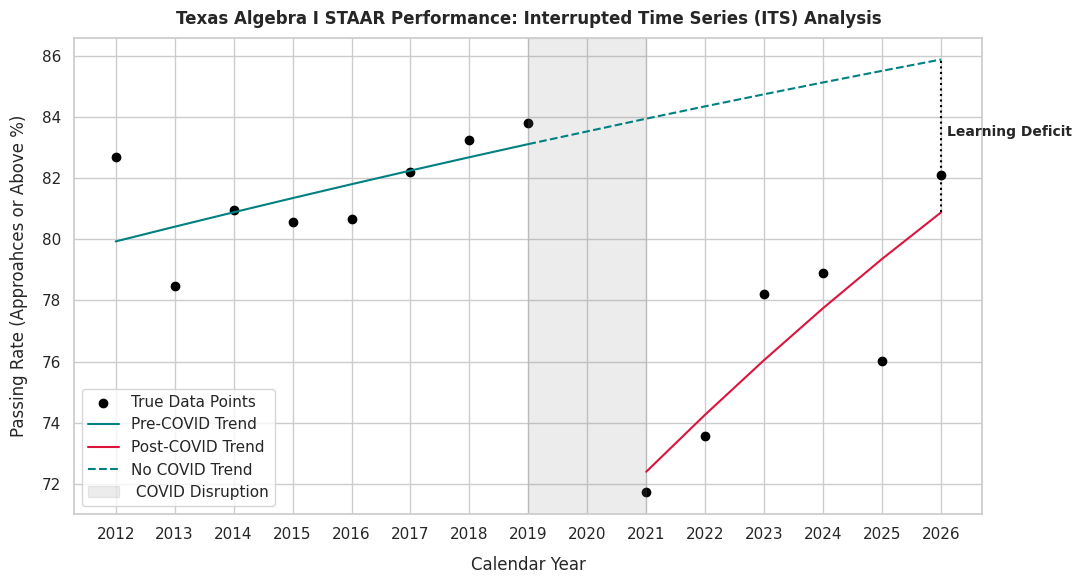

In [6]:
# This entire code block contains code that actually plot and shows the workings
# of our ITS model. A few copies of our Data Frame are made to make the plotting
# of our trendlines more convenient.
sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (11,6))

df_plot = df_model.copy()
df_plot['true_pass_rate'] = (df_plot['passed']) / (df_plot['passed'] + df_plot['failed']) * 100
df_plot['pred_pass_rate'] = its_model.predict(df_plot) * 100

df_noco = df_plot.copy()
df_noco['post_covid'] = 0
df_noco['time_since_COVID'] = 0
df_plot['noco_pass_rate'] = its_model.predict(df_noco) * 100

# These lines here plot the actual averages observed in the Data Frame, as well
# as the fitted projection using the ITS model for the pre-COVID scores
pre_covid_df = df_plot[df_plot['year'] < 2020]
plt.scatter(df_plot['year'], df_plot['true_pass_rate'], color = 'black', label = 'True Data Points')
plt.plot(pre_covid_df['year'], pre_covid_df['pred_pass_rate'], color = 'teal', label = 'Pre-COVID Trend')

# These lines here plot our fitted projections using the ITS model for the post-
# COVID scores.
post_covid_df = df_plot[df_plot['year'] > 2020]
plt.plot(post_covid_df['year'], post_covid_df['pred_pass_rate'], color = 'crimson', label = 'Post-COVID Trend')

# These lines of code here plot our fitted projection using the ITS model if
# COVID never happened.
noco_projection_df = df_plot[df_plot['year'] >= 2019]
plt.plot(noco_projection_df['year'], noco_projection_df['noco_pass_rate'], color = 'teal', linestyle = '--', label = 'No COVID Trend')

# These few lines of code here add the vertical line of our plot showing the
# discrepancy between the projection of where our scores would be without COVID
# intervening, and where our fitted scores were post COVID.
y_actual_2026 = df_plot.loc[df_plot['year'] == 2026, 'pred_pass_rate'].values[0]
y_projected_2026 = df_plot.loc[df_plot['year'] == 2026, 'noco_pass_rate'].values[0]
plt.vlines(x = 2026, ymin = y_actual_2026, ymax = y_projected_2026, color = 'black', linestyle = 'dotted')
plt.text(2026.1, (y_actual_2026 + y_projected_2026) / 2, 'Learning Deficit', weight = 'bold', fontsize = 10)

# These last lines are the final additions for our plot to clean it up by adding
# our legend, titles, shaded area, and our x-ticks.
plt.title('Texas Algebra I STAAR Performance: Interrupted Time Series (ITS) Analysis', weight = 'bold', pad = 10)
plt.xlabel('Calendar Year', labelpad = 10)
plt.ylabel('Passing Rate (Approahces or Above %)', labelpad = 10)
plt.xticks(np.arange(2012, 2027, 1))
plt.axvspan(2019, 2021, color = 'gray', alpha = 0.15, label = ' COVID Disruption')
plt.legend(loc = 'lower left', frameon = True)
plt.tight_layout()

plt.show()

This final bit of code here shows what our ITS (interrupted time series) analysis looks like when graphed. The main point of this is to show exactly how COVID interrupted the progression of the rate of students who passed (i.e. scored in the categories of 'Approaches' or higher), while also highlighting how the post-COVID growth is steeper compared to our pre-COVID growth.

Our 'Pre-COVID Trend' uses the ITS model to fit the 'line of best fit' through the years prior to COVID occurring. Likewise, the 'Post-COVID Trend' uses the ITS model to fit the 'line of best fit' through the year after the occurrence of COVID. The 'No COVID Trend' is the continuation of our 'Pre-COVID Trend' using the ITS model under the consideration that COVID never occurred (i.e. the variables 'post_COVID' and 'time_since_COVID' are both set to a value of 0 like they would be for the years prior to COVID). This allows us to see how the passing rate might have continued to grow if COVID had never interrupted our original growth.

Finally, the 'COVID Disruption' area highlights the year that COVID occurred, which is also why there is no true data point in that window. Furthermore, the 'Learning Deficit' is a line just to point out what the difference in passing rates could potentially be when compared to our trendline that predicts the passing rate if COVID had never happened.